In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
def normalizationData(X):
    return (X - np.mean(X, axis=0)) / np.std(X, axis=0)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def calcLoss(m, y, yPred):
    return -1/m* np.sum(y*np.log(yPred) + (1-y)*np.log(1-yPred))

In [15]:
df= pd.read_csv('Titanic-Dataset.csv')

avgAge= df['Age'].mean()

df['Age']= df['Age'].fillna(avgAge)
df['Sex']= df['Sex'].map({'male': 0, 'female':1})

y = df['Survived'].values
X = df[['Pclass', 'Sex', 'Age', 'SibSp', 'Parch']].values

X = normalizationData(X)


In [17]:
w= np.zeros(X.shape[1])
b = 0

learningRate = 0.006
numIterations = 1800
m=len(y)

lossHistory = []
accuracyHistory = []

for i in range(numIterations):
  z = np.dot(X, w) + b
  yPred = sigmoid(z)
  lossHistory.append(calcLoss(m,y,yPred))

  dz = yPred - y
  dw = (1/m) * np.dot(X.T, dz)
  db = (1/m) * np.sum(dz)
  
  w = w - learningRate * dw
  b = b - learningRate * db

  predictions = (yPred >= 0.5).astype(int)

  accuracy = np.mean(predictions == y)
  accuracyHistory.append(accuracy)

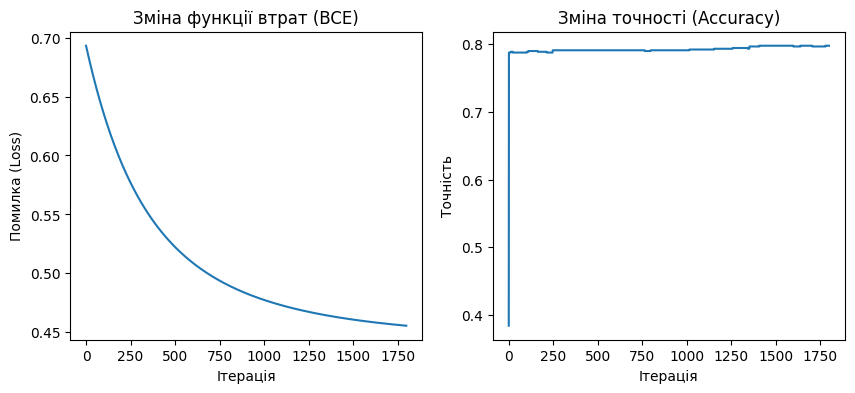

In [18]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1) 
plt.plot(lossHistory)
plt.title('Зміна функції втрат (BCE)')
plt.xlabel('Ітерація')
plt.ylabel('Помилка (Loss)')

plt.subplot(1, 2, 2)
plt.plot(accuracyHistory)
plt.title('Зміна точності (Accuracy)')
plt.xlabel('Ітерація')
plt.ylabel('Точність')

plt.show()